<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.3-training-building-a-cnn-mdc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementación de Unidad Recurrente Bidireccional con Compuerta (BiGRU).

In this notebook vamos a levar a cabo el uso de una *Bidirectional gated recurrent Unit* por sus siglas en ingles *BiGRU*, es una variante avanzada de las Redes Neuronales Recurrentes (RNN) que mejora el procesamiento de secuencias al analizar los datos en ambas direcciones: de principio a fin (hacia adelante) y de fin a principio (hacia atrás). Esta arquitectura combina dos capas de Unidades Recurrentes con Compuerta (GRU) independientes para capturar el contexto tanto pasado como futuro de cada elemento en una secuencia. Para sacar provecho de los canales que conservan la dimension temporal en nuestros tensores, that is los canales correspondientes al delta del mel-spec y a espectrograma *cohclear db*.

It should be noted that, para las primeros bloques de la arquitectura de la Red Neuronal, se usan unidades estandar del tipo Convolusional, de manera que, nuestra arquitectura posee la siguiente estructura base:

## Monitoreo con Weights & Biases

Para optimizar el rendimiento de nuestra arquitectura CBGRU (CNN + BiGRU), integramos Weights & Biases (W&B) como plataforma central de experimentación. En modelos híbridos complejos, es crítico entender cómo interactúan las capas convolucionales y las recurrentes.

**Seguimiento (Tracking)**: Registro en tiempo real de métricas (pérdida, precisión), hiperparámetros y consumo de hardware (GPU/CPU).

**Visualización**: Tableros interactivos para comparar ejecuciones y analizar el rendimiento del modelo.

**Artefactos**: Control de versiones para datasets y modelos, garantizando la trazabilidad y reproducibilidad.

**Barrido (Sweeps)**: Automatización de la búsqueda de los mejores hiperparámetros para optimizar el modelo.

El objetivo es:

* Registrar cada ejecución (hiperparámetros + métricas + artefactos)

* Seleccionar el mejor punto de control usando solo la validación.

* Evaluar una sola vez al final para evitar la fuga de datos de las pruebas.

* Constatar la evolución de los modelos y sus diferentes arquitecturas.

* Obener un modelo final para su inferencia y despliegue a partir de la verificación de su rendimiento despúes de la respectiva experimentación.


### 1.0 Imports y configuración base


In [1]:
# Imports
#------------------------------------------------------------------------------------------
import os
import copy
import numpy as np
import torch
import xgboost as xgb
import random as random
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import time
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchaudio import transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay,f1_score, accuracy_score)
from google.colab import drive
from tqdm import tqdm
from collections import Counter

In [2]:
# ─── Instalación de Weights & Biases ────────────────────────────────
# Descomenta las líneas siguientes si wandb no está instalado en tu entorno:
!pip install wandb -q

# Para autenticarte (solo la primera vez por sesión de Colab):
import wandb; wandb.login()

# USE_WANDB se define en la celda de configuración más abajo.
# Déjalo en False para ejecutar sin tracking remoto.

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: acsalazar (acsalazar-numbral) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
# Semilla y runtime
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


### 1.2 Carga de tensores desde Drive (train/val/test)

Los archivos `.pt` generados en el notebook 3.2 contienen un diccionario con `x`, `y`,
metadatos y el mapeo de clases. Ajusta `BASE_DIR_TENSOR` según tu ruta local/Drive.


In [4]:
drive.mount('/content/drive')
! cp -r /content/drive/MyDrive/split_pytorch_tensors /content/split_pytorch_tensors

Mounted at /content/drive


In [5]:
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
BATCH_SIZE = 32

SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 60, 51)


### 1.3 Estrategia de normalización y augmentation

**Normalización:**  
Los tensores provienen del notebook `3.2` y ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). No se aplica una segunda normalización a nivel de dataset para evitar doble normalización.

**Augmentation online (desactivado por defecto):**  
El notebook `3.2` ya añadió muestras extra de `surprised` con **ruido** y **shift temporal** durante la exportación (augmentación *offline*). Por eso `augment=False` es el valor por defecto en `build_dataloaders`: la augmentación offline ya aporta robustez sin el riesgo de distorsionar demasiado las entradas.  
Si se desea augmentación online adicional, se puede activar `augment=True`; en ese caso se aplica exclusivamente **SpecAugment** (FrequencyMasking + TimeMasking), más un pequeño ruido gaussiano opcional.

**Early stopping y scheduler:**  
Se usa **macro-F1** como criterio en lugar de `val_loss`, ya que es más informativo para datasets desbalanceados y refleja mejor el objetivo de clasificación equitativa entre clases.


In [10]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False):
      self.x = pack['x'].float() # [N, 3, n_mels, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (60x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=6), # Enmascara hasta 4 bins de mel
              T.TimeMasking(time_mask_param=3)       # Enmascara hasta 2 frames de tiempo
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.augment:
          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (Mel spec, delta, Cochlear)
          x = self.spec_aug(x)
          '''
          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + 0.01 * torch.randn_like(x)'''

      return x, y

### 1.4 Configuracion Early Stop

In [7]:
class EarlyStopping:
    """Early stopping configurable para minimizar (val_loss) o maximizar (val_f1)."""
    def __init__(self, patience=5, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode  # "min" para loss, "max" para F1
        self.best = None
        self.counter = 0

    def step(self, metric):
        """Devuelve True cuando se debe detener el entrenamiento."""
        if self.best is None:
            self.best = metric
            return False
        improved = (metric > self.best + self.min_delta) if self.mode == "max" \
                   else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.counter = 0
            return False
        self.counter += 1
        print(f"Early Stopping: {self.counter}/{self.patience} (best={self.best:.4f})")
        return self.counter >= self.patience


### 1.5 Dataloaders

In [11]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
def build_dataloaders(batch_size=BATCH_SIZE):
    pin = torch.cuda.is_available()
    # Valor por defecto: augment= False
    train_ds = TensorPackDataset(train_pack, augment=True)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders()


### 1.6 Definición de la CGRU


In [12]:
class EmotionCGRU(nn.Module):
    def __init__(self, num_classes, classifier_dropout=0.5):
        super().__init__()

        self.cnn = nn.Sequential(
            # Bloque Convolucional 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 60 -> 30, Tiempo: 51 -> 51

            # Bloque Convolucional 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 30 -> 15, Tiempo: 51 -> 51
            nn.Dropout2d(0.25),

            # Bloque Convolucional 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.25),

            # Forzamos frecuencia a 8 (15 -> 8), mantenemos Tiempo intacto con = None -> 51
            nn.AdaptiveAvgPool2d((2, None))
        )

        # 128 canales * 8 bins de frecuencia = 1024
        self.gru_input_size = 128 * 2

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.25
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128), # Estabiliza la salida antes de predecir
            nn.Dropout(classifier_dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Entrada: (Batch, 3, 60, 51)
        x = self.cnn(x) # Salida: (Batch, 128, 8, 51)

        batch_size, channels, freq, time = x.size()

        # Formatear para GRU: (Batch, Tiempo, Features)
        # 1. Permutamos a (Batch, Tiempo, Canales, Frecuencia) -> (Batch, 51, 128, 8)
        x = x.permute(0, 3, 1, 2).contiguous()
        # 2. Aplanamos a (Batch, 51, 1024)
        x = x.view(batch_size, time, channels * freq)

        gru_out, _ = self.bigru(x)
        # Promedio temporal de las salidas de la GRU
        x = gru_out.mean(dim=1)
        return self.classifier(x)

## Tracking con Weights & Biases (W&B)

En los cuadernos de Colab/Jupyter, volver a ejecutar las celdas a menudo sobrescribe variables y resultados, lo que facilita la pérdida de:

* Qué hiperparámetros produjeron el mejor modelo y
las curvas de entrenamiento completas (pérdida/F1 vs. época).

* El mejor punto de control para esa ejecución, la matriz de confusión y
informe de clasificación asociado a ese punto de control.

***W&B*** soluciona esto almacenando las ejecuciones en un registro de experimentos externo, donde cada ejecución incluye:

1. Aspectos de la configuración `(wandb.config)` como for example: `dropout`,`seeds`,`weight decay`,`Learnig rate`, etc.

2. La serie temporal de métricas por época `train val loss`, `macro-F1`, `LR`.

3. Artefactos como puntos de control del modelo e informes.

### 2.0 Configuración de W&B

El baseline se contruye a partir de experimentacion anterior donde se obtuvo mayor estabilidad con un `BATCH_SIZE=32`, y como mencionamos antes sin *online data augmentation*, aunque se conservan estas funcionalidades con motivos investigativos, para futuros usuarios.

In [13]:
# --- Configuración de W&B y matriz de experimentos -----------------------------

# Establece USE_WANDB = True para registrar experimentos en Weights & Biases.
# Requiere wandb instalado (!pip install wandb -q) y autenticado con API key.
USE_WANDB      = True                # ← cambiar a True para activar tracking
WANDB_PROJECT  = "tcoe-experiments-aug-and-drop-aap2"
WANDB_GROUP    = "cnn-cgru-batch32-2"  # agrupa los cuatro experimentos en la misma vista (Mul útil)

# --- Hiperparámetros que son fijos en los cuatro experimentos-------------------

# Baseline confirmado: BATCH_SIZE=32, augment=False (sin SpecAugment online),

EPOCHS              = 50
LABEL_SMOOTHING     = 0.05
MAX_GRAD_NORM       = 1.0
EARLY_STOP_PATIENCE = 8    # patience mayor para que los drops de LR tomen efecto, no usar un valor menor a 4

# Directorio local para guardar los mejores checkpoints por ejecucion
CHECKPOINT_DIR = '/content/checkpoints_cnn'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# --- Matriz de experimentos (4 ejecuciones) ------------------------------------
# Scheduler fijo: ReduceLROnPlateau(mode='max', factor=0.5, patience=2) sobre val macro-F1.
# Gradient clipping: max_norm=1.0.  Label smoothing: 0.05.

RUN_MATRIX = [
    # Run 1 — baseline fuerte: LR conservador, dropout estándar, pesos de clase
    {
        "run_name": "run1_lr3e4_wd1e3_do05_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 2 — LR más alto: explorar convergencia más rápida
    {
        "run_name": "run2_lr5e4_wd1e3_do05_cw",
        "lr": 5e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": True,
    },
    # Run 3 — dropout reducido: menos regularización en el clasificador
    {
        "run_name": "run3_lr3e4_wd1e3_do03_cw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.3,
        "use_class_weights": True,
    },
    # Run 4 — diagnóstico: sin pesos de clase (mide impacto del balanceo)
    {
        "run_name": "run4_lr3e4_wd1e3_do05_nocw",
        "lr": 3e-4, "weight_decay": 1e-3,
        "classifier_dropout": 0.5,
        "use_class_weights": False,
    },
]


### 4. Entrenamiento y validación


In [14]:
# TRAIN
#-------------------------------------------------------------------------------
# Calcular pesos de clase: total / (n_clases * counts)
# Esto da más peso a las clases con menos muestras.
''''surprised' tiene muestras extra desde la exportación offline, por lo que su peso
    resultante será menor que otras clases sub-representadas.'''

y_train_cpu = train_pack['y'].numpy()
label_counts = Counter(y_train_cpu)
total_samples = len(y_train_cpu)
num_classes = len(class_names)

class_weights = []
for i in range(num_classes):
    count = label_counts.get(i, 1)
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Pesos calculados para CrossEntropyLoss: {class_weights}")


def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping para estabilizar el entrenamiento del GRU
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# VAL
#-------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [val]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    # Macro-F1: métrica clave para datasets desbalanceados con objetivo de clasificación equitativa
    epoch_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1


# TEST / PREDICCIONES
#-------------------------------------------------------------------------------
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_targets), np.concatenate(all_preds)


Pesos calculados para CrossEntropyLoss: [0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9638961038961039, 0.9000727625515401, 2.4543650793650795]



  INICIANDO: run1_lr3e4_wd1e3_do05_cw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=True



[22:46:31] Epoca 01/50 | Train loss 1.8037 acc 0.2656 | Val loss 1.7763 acc 0.3098 f1 0.2470 | lr 3.0e-04 | Time 8.9s


[22:46:39] Epoca 02/50 | Train loss 1.6454 acc 0.3465 | Val loss 1.6728 acc 0.3397 f1 0.3037 | lr 3.0e-04 | Time 7.9s


[22:46:46] Epoca 03/50 | Train loss 1.5739 acc 0.3825 | Val loss 1.6438 acc 0.3600 f1 0.3183 | lr 3.0e-04 | Time 6.8s


[22:46:54] Epoca 04/50 | Train loss 1.5091 acc 0.4132 | Val loss 1.6165 acc 0.4127 f1 0.3679 | lr 3.0e-04 | Time 7.9s


...

[22:50:42] Epoca 35/50 | Train loss 1.0565 acc 0.6315 | Val loss 1.3431 acc 0.5371 f1 0.5403 | lr 1.9e-05 | Time 6.8s
Early Stopping: 4/8 (best=0.5573)


[22:50:50] Epoca 36/50 | Train loss 1.0612 acc 0.6370 | Val loss 1.3349 acc 0.5383 f1 0.5442 | lr 1.9e-05 | Time 7.7s
Early Stopping: 5/8 (best=0.5573)


[22:50:57] Epoca 37/50 | Train loss 1.0577 acc 0.6393 | Val loss 1.3284 acc 0.5467 f1 0.5526 | lr 9.4e-06 | Time 6.6s
Early Stopping: 6/8 (best=0.5573)


[22:51:04] Epoca 38/50 | Train loss 1.0485 acc 0.6443 | Val loss 1.3387 acc 0.5419 f1 0.5507 | lr 9.4e-06 | Time 7.7s
Early Stopping: 7/8 (best=0.5573)


[22:51:11] Epoca 39/50 | Train loss 1.0407 acc 0.6482 | Val loss 1.3389 acc 0.5443 f1 0.5508 | lr 9.4e-06 | Time 6.7s
Early Stopping: 8/8 (best=0.5573)
Early stopping en epoch 39 (best val_f1=0.5573)

--- RESULTADO TEST [run1_lr3e4_wd1e3_do05_cw] ---
  best_epoch=31  best_val_f1=0.5573
  test_macro_f1=0.5530  test_acc=0.5647
              precision    recall  f1-score   support

       angry       0.70      0.79      0.74       149
     disgust       0.48      0.58      0.52       149
     fearful       0.61      0.35      0.44       149
       happy       0.60      0.49      0.54       149
     neutral       0.50      0.73      0.59       143
         sad       0.58      0.46      0.52       149
   surprised       0.47      0.58      0.52        24

    accuracy                           0.56       912
   macro avg       0.56      0.57      0.55       912
weighted avg       0.58      0.56      0.56       912



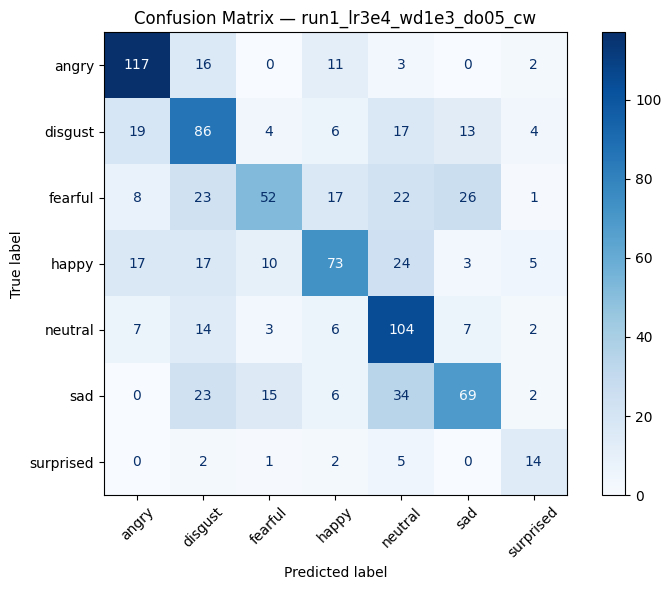

lr,█████████████▄▄▄▄▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇███████████
train_loss,█▇▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▄▄▄▅▅▅▆▇▆▆▆▆▆▇▇▆▇▇▇█▇▇▇█▇███████████
val_loss,█▆▆▆▄▅▄▄▄▃▂▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▂▁▁▁▁▁▁▁▁▁
val_macro_f1,▁▂▃▄▅▄▅▅▆▆▇▆▆▇▆▇▇▇▆▇▇▇█▇▇▇█████████████
lr,1e-05
test_acc,0.56469
test_macro_f1,0.55298



  INICIANDO: run2_lr5e4_wd1e3_do05_cw
  lr=0.0005  wd=0.001  dropout=0.5  class_weights=True



[22:51:24] Epoca 01/50 | Train loss 1.7661 acc 0.2881 | Val loss 1.8089 acc 0.2943 f1 0.2357 | lr 5.0e-04 | Time 7.4s


[22:51:32] Epoca 02/50 | Train loss 1.5910 acc 0.3775 | Val loss 1.6699 acc 0.3756 f1 0.3390 | lr 5.0e-04 | Time 7.8s


[22:51:40] Epoca 03/50 | Train loss 1.5173 acc 0.4104 | Val loss 1.6003 acc 0.3756 f1 0.3440 | lr 5.0e-04 | Time 7.4s


...

[22:54:46] Epoca 28/50 | Train loss 1.0000 acc 0.6613 | Val loss 1.3654 acc 0.5359 f1 0.5366 | lr 6.3e-05 | Time 7.1s
Early Stopping: 4/8 (best=0.5525)


[22:54:54] Epoca 29/50 | Train loss 0.9947 acc 0.6706 | Val loss 1.3721 acc 0.5443 f1 0.5365 | lr 6.3e-05 | Time 7.5s
Early Stopping: 5/8 (best=0.5525)


[22:55:01] Epoca 30/50 | Train loss 0.9869 acc 0.6717 | Val loss 1.3737 acc 0.5455 f1 0.5452 | lr 3.1e-05 | Time 7.0s
Early Stopping: 6/8 (best=0.5525)


[22:55:08] Epoca 31/50 | Train loss 0.9785 acc 0.6741 | Val loss 1.3834 acc 0.5407 f1 0.5360 | lr 3.1e-05 | Time 7.7s
Early Stopping: 7/8 (best=0.5525)


[22:55:15] Epoca 32/50 | Train loss 0.9749 acc 0.6888 | Val loss 1.3672 acc 0.5431 f1 0.5389 | lr 3.1e-05 | Time 7.0s
Early Stopping: 8/8 (best=0.5525)
Early stopping en epoch 32 (best val_f1=0.5525)

--- RESULTADO TEST [run2_lr5e4_wd1e3_do05_cw] ---
  best_epoch=24  best_val_f1=0.5525
  test_macro_f1=0.5778  test_acc=0.5811
              precision    recall  f1-score   support

       angry       0.72      0.76      0.74       149
     disgust       0.45      0.63      0.53       149
     fearful       0.72      0.39      0.51       149
       happy       0.59      0.50      0.54       149
     neutral       0.52      0.76      0.62       143
         sad       0.61      0.46      0.52       149
   surprised       0.71      0.50      0.59        24

    accuracy                           0.58       912
   macro avg       0.62      0.57      0.58       912
weighted avg       0.61      0.58      0.58       912



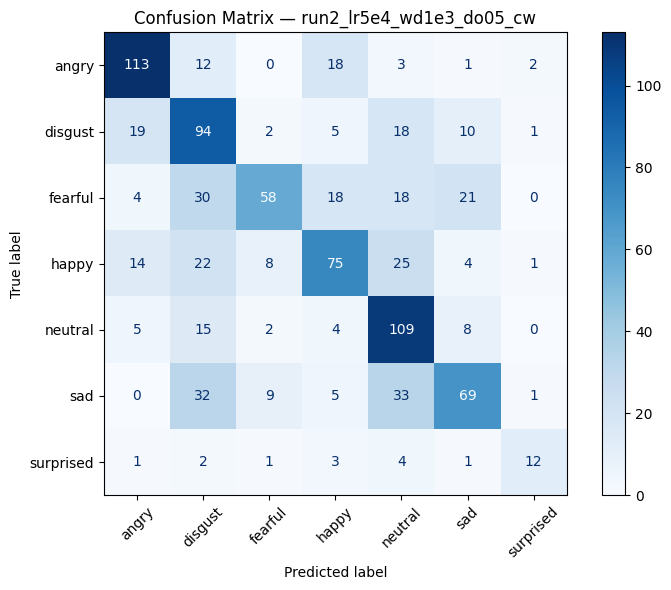

lr,████████████▄▄▄▄▄▄▄▂▂▂▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇█████
train_loss,█▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▃▅▅▅▆▆▆▆▆▅▆▇▇▇█▇▇▇███████▇████
val_loss,█▆▅▄▃▅▃▃▃▂▂▄▂▁▂▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁
val_macro_f1,▁▃▃▅▅▅▆▆▆▇▆▆▆▇▇▇██▇█████████████
lr,3e-05
test_acc,0.58114
test_macro_f1,0.57783



  INICIANDO: run3_lr3e4_wd1e3_do03_cw
  lr=0.0003  wd=0.001  dropout=0.3  class_weights=True



[22:55:28] Epoca 01/50 | Train loss 1.7638 acc 0.2820 | Val loss 1.7426 acc 0.3325 f1 0.2771 | lr 3.0e-04 | Time 7.3s


[22:55:36] Epoca 02/50 | Train loss 1.6069 acc 0.3655 | Val loss 1.6926 acc 0.3493 f1 0.3022 | lr 3.0e-04 | Time 8.2s


[22:55:43] Epoca 03/50 | Train loss 1.5408 acc 0.3964 | Val loss 1.6042 acc 0.3780 f1 0.3409 | lr 3.0e-04 | Time 7.1s


...

[23:01:16] Epoca 46/50 | Train loss 0.9574 acc 0.6805 | Val loss 1.3749 acc 0.5514 f1 0.5542 | lr 1.9e-05 | Time 8.4s
Early Stopping: 2/8 (best=0.5621)


[23:01:23] Epoca 47/50 | Train loss 0.9561 acc 0.6816 | Val loss 1.3709 acc 0.5514 f1 0.5514 | lr 9.4e-06 | Time 7.3s
Early Stopping: 3/8 (best=0.5621)


[23:01:31] Epoca 48/50 | Train loss 0.9473 acc 0.6854 | Val loss 1.3763 acc 0.5514 f1 0.5532 | lr 9.4e-06 | Time 8.2s
Early Stopping: 4/8 (best=0.5621)


[23:01:39] Epoca 49/50 | Train loss 0.9561 acc 0.6801 | Val loss 1.3870 acc 0.5502 f1 0.5508 | lr 9.4e-06 | Time 7.2s
Early Stopping: 5/8 (best=0.5621)


[23:01:47] Epoca 50/50 | Train loss 0.9481 acc 0.6854 | Val loss 1.3755 acc 0.5455 f1 0.5471 | lr 4.7e-06 | Time 8.3s
Early Stopping: 6/8 (best=0.5621)

--- RESULTADO TEST [run3_lr3e4_wd1e3_do03_cw] ---
  best_epoch=44  best_val_f1=0.5621
  test_macro_f1=0.5723  test_acc=0.5822
              precision    recall  f1-score   support

       angry       0.72      0.78      0.75       149
     disgust       0.48      0.58      0.52       149
     fearful       0.66      0.45      0.53       149
       happy       0.60      0.46      0.52       149
     neutral       0.53      0.71      0.60       143
         sad       0.58      0.54      0.56       149
   surprised       0.55      0.50      0.52        24

    accuracy                           0.58       912
   macro avg       0.59      0.57      0.57       912
weighted avg       0.59      0.58      0.58       912



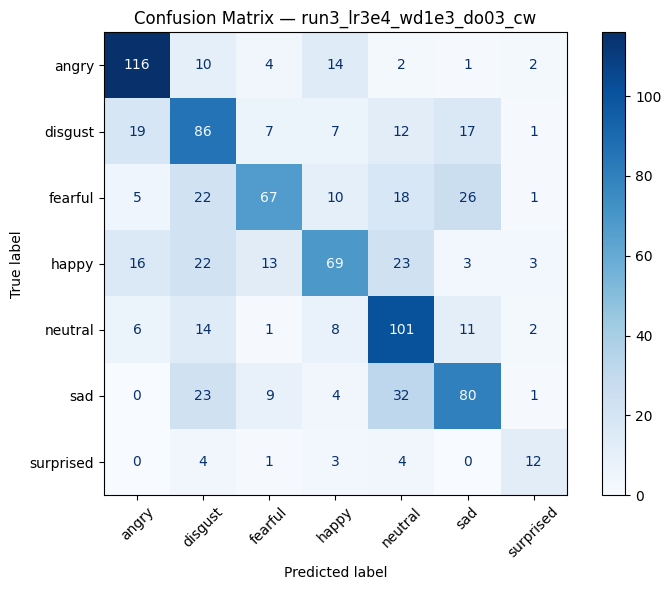

lr,██████████████▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▂▃▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▄▅▅▅▅▆▆▆▆▆▇▇▇▇█▇▇█▇▇▇███████████████
val_loss,█▇▆▅▅▄▃▃▂▄▂▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▂▂▁▁▁▂▂▂▁▂▂▂▂
val_macro_f1,▁▂▃▃▄▅▅▆▆▆▆▇▆▆▆▇▇▇▇█▇███████████████████
lr,0.0
test_acc,0.58224
test_macro_f1,0.57229



  INICIANDO: run4_lr3e4_wd1e3_do05_nocw
  lr=0.0003  wd=0.001  dropout=0.5  class_weights=False



[23:02:00] Epoca 01/50 | Train loss 1.8539 acc 0.2776 | Val loss 1.7522 acc 0.3349 f1 0.2587 | lr 3.0e-04 | Time 8.2s


[23:02:07] Epoca 02/50 | Train loss 1.6880 acc 0.3518 | Val loss 1.6440 acc 0.3636 f1 0.3244 | lr 3.0e-04 | Time 7.1s


[23:02:16] Epoca 03/50 | Train loss 1.6095 acc 0.3863 | Val loss 1.5997 acc 0.3852 f1 0.3266 | lr 3.0e-04 | Time 8.1s


...

[23:05:33] Epoca 29/50 | Train loss 1.1421 acc 0.6097 | Val loss 1.3365 acc 0.5359 f1 0.5417 | lr 1.9e-05 | Time 7.7s
Early Stopping: 4/8 (best=0.5429)


[23:05:40] Epoca 30/50 | Train loss 1.1450 acc 0.6149 | Val loss 1.3397 acc 0.5311 f1 0.5355 | lr 1.9e-05 | Time 7.3s
Early Stopping: 5/8 (best=0.5429)


[23:05:48] Epoca 31/50 | Train loss 1.1359 acc 0.6126 | Val loss 1.3366 acc 0.5347 f1 0.5425 | lr 9.4e-06 | Time 7.8s
Early Stopping: 6/8 (best=0.5429)


[23:05:55] Epoca 32/50 | Train loss 1.1362 acc 0.6117 | Val loss 1.3318 acc 0.5323 f1 0.5327 | lr 9.4e-06 | Time 7.4s
Early Stopping: 7/8 (best=0.5429)


[23:06:03] Epoca 33/50 | Train loss 1.1339 acc 0.6187 | Val loss 1.3302 acc 0.5371 f1 0.5411 | lr 9.4e-06 | Time 7.8s
Early Stopping: 8/8 (best=0.5429)
Early stopping en epoch 33 (best val_f1=0.5429)

--- RESULTADO TEST [run4_lr3e4_wd1e3_do05_nocw] ---
  best_epoch=25  best_val_f1=0.5429
  test_macro_f1=0.5633  test_acc=0.5647
              precision    recall  f1-score   support

       angry       0.74      0.75      0.74       149
     disgust       0.48      0.55      0.51       149
     fearful       0.62      0.37      0.46       149
       happy       0.55      0.50      0.52       149
     neutral       0.47      0.76      0.58       143
         sad       0.61      0.48      0.53       149
   surprised       0.71      0.50      0.59        24

    accuracy                           0.56       912
   macro avg       0.60      0.56      0.56       912
weighted avg       0.58      0.56      0.56       912



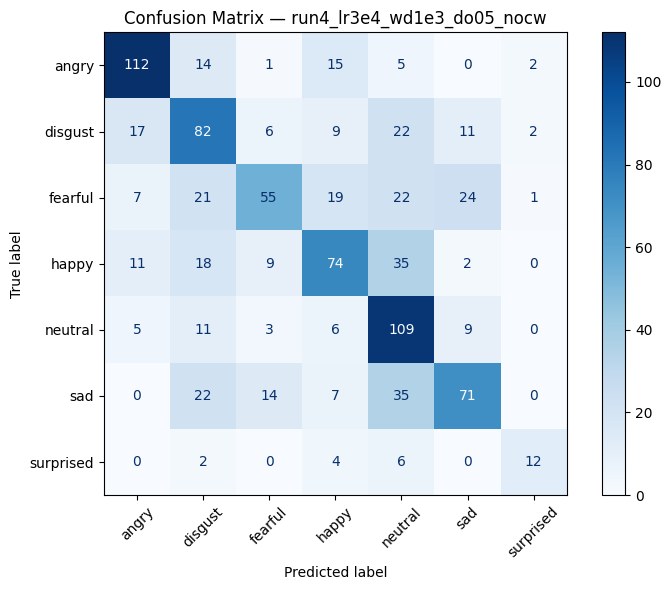

lr,███████████▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
test_acc,▁
test_macro_f1,▁
train_acc,▁▃▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▆▆▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▂▃▃▃▄▅▅▅▅▆▅▆▇▆▇▇▇█▇█▇█▇█████████
val_loss,█▆▅▆▄▅▄▄▃▃▃▄▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁
val_macro_f1,▁▃▃▂▄▄▅▄▆▅▅▅▆█▇▇▆▇█▇█▇█▇█████████
lr,1e-05
test_acc,0.56469
test_macro_f1,0.56326


In [15]:
# ─── Entrenamiento multi-experimento con W&B ──────────────────────────────────
all_run_results = []

for run_cfg in RUN_MATRIX:
    run_name           = run_cfg["run_name"]
    lr                 = run_cfg["lr"]
    weight_decay       = run_cfg["weight_decay"]
    classifier_dropout = run_cfg["classifier_dropout"]
    use_class_weights  = run_cfg["use_class_weights"]

    print(f"\n{'='*70}")
    print(f"  INICIANDO: {run_name}")
    print(f"  lr={lr}  wd={weight_decay}  dropout={classifier_dropout}  class_weights={use_class_weights}")
    print(f"{'='*70}\n")

    # Reproducibilidad por ejecucion
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.cuda.manual_seed_all(42)

    # Dataloaders frescos para cada ejecucion
    train_loader, val_loader, test_loader = build_dataloaders()

    # Modelo con el dropout del clasificador según la ejecucion
    model = EmotionCGRU(num_classes=len(class_names), classifier_dropout=classifier_dropout).to(device)

    # Función de pérdida
    criterion_weights = class_weights_tensor if use_class_weights else None
    criterion = nn.CrossEntropyLoss(weight=criterion_weights, label_smoothing=LABEL_SMOOTHING)

    # Optimizador y scheduler
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler    = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    early_stopper = EarlyStopping(patience=EARLY_STOP_PATIENCE, min_delta=1e-4, mode='max')

    # Inicializar W&B
    if USE_WANDB:
        import wandb
        wandb.init(
            project=WANDB_PROJECT,
            group=WANDB_GROUP,
            name=run_name,
            config={
                "lr":                 lr,
                "weight_decay":       weight_decay,
                "classifier_dropout": classifier_dropout,
                "use_class_weights":  use_class_weights,
                "label_smoothing":    LABEL_SMOOTHING,
                "batch_size":         BATCH_SIZE,
                "epochs":             EPOCHS,
                "early_stop_patience": EARLY_STOP_PATIENCE,
                "max_grad_norm":      MAX_GRAD_NORM,
                "augment_online":     True,
                "model":              "EmotionCGRU",
            },
        )

    best_val_f1 = 0.0
    best_epoch  = 0
    best_state  = copy.deepcopy(model.state_dict())

    for epoch in range(1, EPOCHS + 1):
        start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            epoch=epoch, max_grad_norm=MAX_GRAD_NORM,
        )
        val_loss, val_acc, val_f1 = evaluate(
            model, val_loader, criterion, device, epoch=epoch,
        )

        scheduler.step(val_f1)
        current_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - start

        print(
            f"[{time.strftime('%H:%M:%S')}] Epoca {epoch:02d}/{EPOCHS:02d} | "
            f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
            f"lr {current_lr:.1e} | Time {elapsed:.1f}s"
        )

        if USE_WANDB:
            wandb.log({
                "train_loss":   train_loss,
                "train_acc":    train_acc,
                "val_loss":     val_loss,
                "val_acc":      val_acc,
                "val_macro_f1": val_f1,
                "lr":           current_lr,
            }, step=epoch)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch  = epoch
            best_state  = copy.deepcopy(model.state_dict())
            ckpt_path   = os.path.join(CHECKPOINT_DIR, f"{run_name}_best.pth")
            torch.save(best_state, ckpt_path)

        if early_stopper.step(val_f1):
            print(f"Early stopping en epoch {epoch} (best val_f1={best_val_f1:.4f})")
            break

    # ── Evaluación en test (una sola vez, con el mejor modelo por val_f1) ──────
    model.load_state_dict(best_state)
    y_true, y_pred = get_predictions(model, test_loader, device)
    test_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_true, y_pred)

    print(f"\n--- RESULTADO TEST [{run_name}] ---")
    print(f"  best_epoch={best_epoch}  best_val_f1={best_val_f1:.4f}")
    print(f"  test_macro_f1={test_f1:.4f}  test_acc={test_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax_cm, cmap='Blues', xticks_rotation=45, values_format='d')
    ax_cm.set_title(f"Confusion Matrix — {run_name}")
    plt.tight_layout()
    plt.show()

    if USE_WANDB:
        # Guardar y loggear el checkpoint como artefacto
        artifact = wandb.Artifact(name=f"model_{run_name}", type="model")
        artifact.add_file(ckpt_path)
        wandb.log_artifact(artifact)

        # Métricas y artefactos de test
        report_dict = classification_report(
            y_true, y_pred, target_names=class_names, output_dict=True)
        wandb.log({
            "test_macro_f1":       test_f1,
            "test_acc":            test_acc,
            "confusion_matrix":    wandb.Image(fig_cm),
            "classification_report": wandb.Table(
                columns=["class", "precision", "recall", "f1-score", "support"],
                data=[
                    [c,
                     report_dict[c]["precision"],
                     report_dict[c]["recall"],
                     report_dict[c]["f1-score"],
                     int(report_dict[c]["support"])]
                    for c in class_names
                ],
            ),
        })
        wandb.finish()

    all_run_results.append({
        "run_name":      run_name,
        "best_val_f1":   round(best_val_f1, 4),
        "best_epoch":    best_epoch,
        "test_macro_f1": round(test_f1, 4),
        "test_acc":      round(test_acc, 4),
    })
    plt.close('all')


### 5. Resumen de experimentos y evaluación final


In [16]:
# Tabla resumen de la experimentación -----------------------------------------------
summary_df = pd.DataFrame(all_run_results)
summary_df = summary_df.sort_values("best_val_f1", ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("  RESUMEN FINAL DE EXPERIMENTOS")
print("="*70)
print(summary_df.to_string(index=False))
display(summary_df)



  RESUMEN FINAL DE EXPERIMENTOS
                  run_name  best_val_f1  best_epoch  test_macro_f1  test_acc
  run3_lr3e4_wd1e3_do03_cw       0.5621          44         0.5723    0.5822
  run1_lr3e4_wd1e3_do05_cw       0.5573          31         0.5530    0.5647
  run2_lr5e4_wd1e3_do05_cw       0.5525          24         0.5778    0.5811
run4_lr3e4_wd1e3_do05_nocw       0.5429          25         0.5633    0.5647


,run_name,best_val_f1,best_epoch,test_macro_f1,test_acc
0,run3_lr3e4_wd1e3_do03_cw,0.5621,44,0.5723,0.5822
1,run1_lr3e4_wd1e3_do05_cw,0.5573,31,0.5530,0.5647
2,run2_lr5e4_wd1e3_do05_cw,0.5525,24,0.5778,0.5811
3,run4_lr3e4_wd1e3_do05_nocw,0.5429,25,0.5633,0.5647


## Modelos tradicionales de ML con Grid Search

Se entrenan **Random Forest** y **XGBoost** con búsqueda de hiperparámetros usando
`GridSearchCV` con `PredefinedSplit` para respetar la partición train/val sin filtrar
el set de test. Antes del entrenamiento se aplica **SMOTE** exclusivamente sobre el
conjunto de entrenamiento para balancear la clase minoritaria `surprised`.


In [17]:
def pack_to_numpy(pack):
    x = pack['x'].float().reshape(pack['x'].shape[0], -1).numpy()
    y = pack['y'].numpy()
    return x, y

X_train, y_train = pack_to_numpy(train_pack)
X_val, y_val = pack_to_numpy(val_pack)
X_test, y_test = pack_to_numpy(test_pack)
X_train_val = np.concatenate([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val], axis=0)


print(f"Muestras por clase:")
for cls, idx in sorted(class_to_idx.items(), key=lambda kv: kv[1]):
    print(f"  {cls:12s} (idx={idx}): {(y_train == idx).sum()}")

# -1 = train, 0 = val (PredefinedSplit usa índice de fold)
test_fold = np.concatenate([
    -1 * np.ones(len(X_train), dtype=int),
     np.zeros(len(X_val), dtype=int)
])
predefined_split = PredefinedSplit(test_fold)
print(f"\nTamaño total train+val para GridSearchCV: {len(X_train_val)}")
print(f"(train={len(X_train)}, val={len(X_val)}, test={len(X_test)} — test NO entra en GridSearch)")


Muestras por clase:
  angry        (idx=0): 1178
  disgust      (idx=1): 1178
  fearful      (idx=2): 1178
  happy        (idx=3): 1178
  neutral      (idx=4): 1100
  sad          (idx=5): 1178
  surprised    (idx=6): 432

Tamaño total train+val para GridSearchCV: 8258
(train=7422, val=836, test=912 — test NO entra en GridSearch)


In [ ]:
# ── Random Forest con Grid Search ────────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [20, 60],
    'max_depth': [20, None],
    'min_samples_split': [2, 6],
    'min_samples_leaf': [1, 7],
    'max_features': ['log2'],
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_train_val, y_train_val)

print('RF — Mejores parámetros:', grid_rf.best_params_)
print('RF — Mejor f1_macro (val):', grid_rf.best_score_)


Fitting 1 folds for each of 16 candidates, totalling 16 fits
RF — Mejores parámetros: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 60}
RF — Mejor f1_macro (val): 0.33904274294423553


=== Random Forest — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.62      0.62      0.62       149
     disgust       0.33      0.26      0.29       149
     fearful       0.28      0.12      0.17       149
       happy       0.40      0.34      0.37       149
     neutral       0.34      0.49      0.40       143
         sad       0.48      0.48      0.48       149
   surprised       0.10      0.42      0.16        24

    accuracy                           0.38       912
   macro avg       0.36      0.39      0.35       912
weighted avg       0.40      0.38      0.38       912



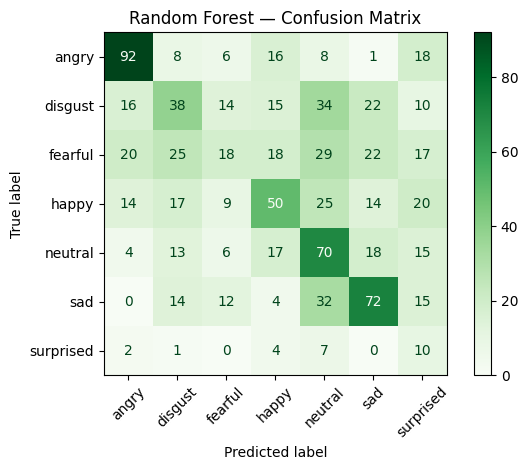

In [ ]:
best_rf = RandomForestClassifier(**grid_rf.best_params_, random_state=42, class_weight='balanced', n_jobs=-1)
best_rf.fit(X_train_val, y_train_val)
y_pred_rf = best_rf.predict(X_test)
print('=== Random Forest — Evaluación en Test ===')
print(classification_report(y_test, y_pred_rf, target_names=class_names))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(cmap='Greens', xticks_rotation=45)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# ── XGBoost con Grid Search ───────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators': [30],
    'max_depth': [3],
    'learning_rate': [0.01],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names),
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='merror',
    random_state=42,
    n_jobs=-1,
)
grid_xgb = GridSearchCV(
    xgb_clf,
    param_grid=param_grid_xgb,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1, # Changed from 1 to -1 to use all available cores
    verbose=1,
)
grid_xgb.fit(X_train_val, y_train_val)

print('XGB — Mejores parámetros:', grid_xgb.best_params_)
print('XGB — Mejor f1_macro (val):', grid_xgb.best_score_)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:51:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB — Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 30, 'subsample': 0.8}
XGB — Mejor f1_macro (val): 0.29780300025493417


=== XGBoost — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.47      0.68      0.55       149
     disgust       0.35      0.36      0.35       149
     fearful       0.31      0.20      0.24       149
       happy       0.33      0.38      0.35       149
     neutral       0.30      0.10      0.15       143
         sad       0.41      0.62      0.49       149
   surprised       0.00      0.00      0.00        24

    accuracy                           0.38       912
   macro avg       0.31      0.33      0.31       912
weighted avg       0.35      0.38      0.35       912



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


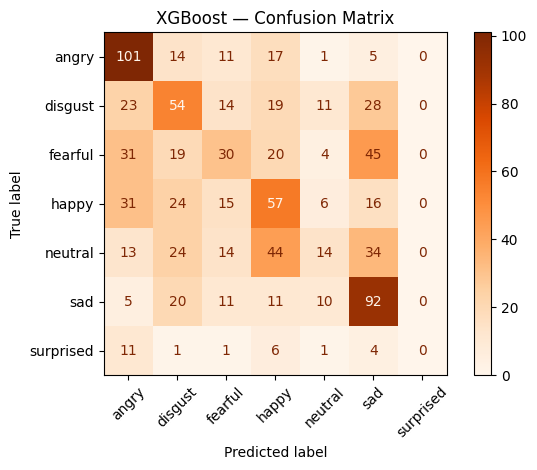

In [ ]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print('=== XGBoost — Evaluación en Test ===')
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=class_names).plot(cmap='Oranges', xticks_rotation=45)
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()
